In [1]:
import fdfi
print('FDFI version:', fdfi.__version__)

FDFI version: 0.0.9


# EOTExplainer: Semicontinuous Entropic Optimal Transport

This tutorial covers the `EOTExplainer`, which uses **semicontinuous entropic optimal transport** with **population backward attribution** (best linear projection) to compute disentangled feature importance.

## What You'll Learn

1. How EOT whitening + semicontinuous transport disentangles features
2. How the population backward attribution maps Z-importance to X-importance
3. How to run attribution inference with confidence intervals
4. How epsilon controls the transport shrinkage


In [2]:
import numpy as np
from fdfi.explainers import EOTExplainer
from fdfi.plots import confidence_interval_plot, diagnostics_plot, summary_bar

np.random.seed(42)


## Why Semicontinuous EOT?

Gaussian OT whitens data via $\Sigma^{-1/2}$, which assumes linear structure. **Semicontinuous EOT** solves the entropic transport problem between the empirical source and a continuous $\mathcal{N}(0, I)$ target analytically:

$$Z = s \cdot X_{\text{whitened}}, \quad s = \frac{2}{2 + \varepsilon}$$

The **population backward attribution** computes the best linear projection $E[X_w \mid Z]$ using the analytically known coupling moments:

$$M_w = E_\pi[ZZ^\top]^{-1} E_\pi[ZX_w^\top]$$

Then the weight matrix $W = L \cdot M_w$ maps Z-space importance to X-space via:

$$\phi_{X,j} = \sum_k W_{jk}^2 \cdot \phi_{Z,k}$$


## Synthetic Data: Relevant vs Null Features

We build a dataset with correlated features. The model directly uses $X_0, X_2, X_4$, but because $X_1$ is highly correlated with $X_0$ ($\rho = 0.7$) and $X_3$ is correlated with $X_2$ ($\rho = 0.5$), they also carry predictive signal. FDFI's design goal is to detect **all features that provide predictive information**, so the relevant set is $\{X_0, X_1, X_2, X_3, X_4\}$, while $X_5, \ldots, X_9$ are truly null.

In [3]:
# Correlated synthetic data with known active features
n_train = 400
n_test = 150
d = 10

# Build a covariance matrix with block correlations
rng = np.random.default_rng(42)
Sigma = np.eye(d)
# Correlate features 0-1 and 2-3
Sigma[0, 1] = Sigma[1, 0] = 0.7
Sigma[2, 3] = Sigma[3, 2] = 0.5

X_train = rng.multivariate_normal(np.zeros(d), Sigma, size=n_train)
X_test = rng.multivariate_normal(np.zeros(d), Sigma, size=n_test)

# Model directly uses features 0, 2, 4
active_idx = [0, 2, 4]
# Features 1 and 3 carry predictive signal via correlation
# → all 5 are "relevant"; features 5-9 are truly null
relevant_idx = [0, 1, 2, 3, 4]
null_idx = [5, 6, 7, 8, 9]

def exp_model(X):
    return 3.0 * X[:, 0] + 2.0 * X[:, 2] + 1.5 * X[:, 4]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Relevant features:", relevant_idx, "(model uses 0,2,4; 1,3 correlated)")
print("Null features:", null_idx)
print("Correlation(X0, X1):", f"{np.corrcoef(X_train[:, 0], X_train[:, 1])[0, 1]:.3f}")
print("Correlation(X2, X3):", f"{np.corrcoef(X_train[:, 2], X_train[:, 3])[0, 1]:.3f}")

Train shape: (400, 10)
Test shape: (150, 10)
Relevant features: [0, 1, 2, 3, 4] (model uses 0,2,4; 1,3 correlated)
Null features: [5, 6, 7, 8, 9]
Correlation(X0, X1): 0.684
Correlation(X2, X3): 0.481


In [4]:
# Sanity check: model predictions
y_preview = exp_model(X_test[:5])
print("Preview predictions:", np.round(y_preview, 3))
print("Response variance:", f"{np.var(exp_model(X_train)):.3f}")


Preview predictions: [-0.623 -0.873 -2.557  3.994 -1.331]
Response variance: 14.504


## Basic EOTExplainer Usage

Create an explainer, compute importance, and inspect results.


In [5]:
explainer = EOTExplainer(
    exp_model,
    data=X_train,
    nsamples=60,
    auto_epsilon=True,
    random_state=0,
)

results = explainer(X_test)
phi_X = results["phi_X"]

print("Feature importance (phi_X):")
print("-" * 55)
print(f"{'Feature':>8} {'phi_X':>10} {'Status':>12}")
print("-" * 55)
for i in range(d):
    status = "model" if i in active_idx else ("correlated" if i in relevant_idx else "null")
    print(f"{'X_' + str(i):>8} {phi_X[i]:>10.4f} {status:>12}")

print(f"\nAuto epsilon: {explainer.epsilon:.4f}")
print(f"Forward shrinkage s: {explainer.s_fwd:.4f}")
print(f"Backward weight matrix W shape: {explainer.W.shape}")

Feature importance (phi_X):
-------------------------------------------------------
 Feature      phi_X       Status
-------------------------------------------------------
     X_0     6.2095        model
     X_1     1.9614   correlated
     X_2     3.6030        model
     X_3     0.5729   correlated
     X_4     1.6349        model
     X_5     0.0253         null
     X_6     0.0245         null
     X_7     0.0353         null
     X_8     0.0266         null
     X_9     0.0177         null

Auto epsilon: 0.4700
Forward shrinkage s: 0.9817
Backward weight matrix W shape: (10, 10)


(<Figure size 800x490 with 1 Axes>,
 <Axes: title={'center': 'Global FDFI Feature Importance'}, xlabel='Mean absolute FDFI score', ylabel='Feature'>,
   feature       phi        se
 0      X0  6.209546  0.677328
 1      X2  3.602960  0.488144
 2      X1  1.961412  0.148960
 3      X4  1.634898  0.184264
 4      X3  0.572852  0.056102
 5      X7  0.035337  0.003481
 6      X8  0.026584  0.002892
 7      X5  0.025260  0.002967
 8      X6  0.024505  0.002845
 9      X9  0.017693  0.002347)

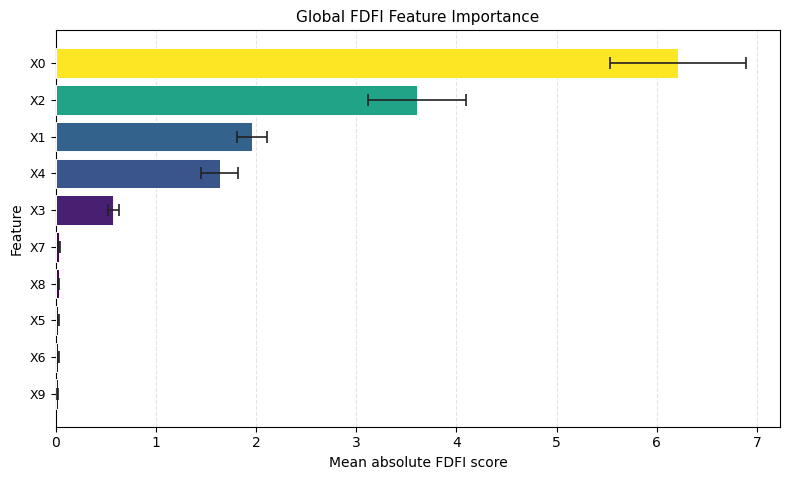

In [6]:
feature_names = [f"X{i}" for i in range(d)]

summary_bar(
    results["phi_X"],
    results["se_X"],
    feature_names,
    show=False,
)

## Attribution Inference

Use one-sided testing to identify features with significant predictive importance. We expect all 5 relevant features ($X_0$–$X_4$) to be detected, while the 5 null features ($X_5$–$X_9$) should not.

In [7]:
# Default conf_int: margin_method="auto" (gap for d<30, mixture for d>=30)
ci = explainer.conf_int(
    alpha=0.05,
    target="X",
    alternative="greater",
    verbose=True,
)

attribution_idx = np.where(ci["reject_null"])[0]
expected = set(relevant_idx)
detected = set(attribution_idx.tolist())

print(f"\nMargin method: {ci['margin_method']}, margin: {ci['margin']:.4f}")
print("Detected features:", sorted(detected))
print("Relevant features:", sorted(expected))
print("True positives:", sorted(expected & detected))
print("False positives:", sorted(detected - expected))
print("Missed:", sorted(expected - detected))
print()
for i in range(d):
    tag = "*" if ci["reject_null"][i] else ""
    status = "model" if i in active_idx else ("corr" if i in relevant_idx else "null")
    print(f"  X_{i} [{status:>5}]: phi={ci['score'][i]:.4f}  se={ci['se'][i]:.4f}"
          f"  z={ci['zscore'][i]:.2f}  rank={ci['ranking'][i]:>2}  p={ci['pvalue'][i]:.4f} {tag}")


[margin] method=auto → gap (d=10 < 30)
[margin] gap: sorted phi range [0.0177, 6.2095], largest log-gap between rank 4 (0.0353) and 5 (0.5729), ratio=16.2x, margin=0.0353

Margin method: gap, margin: 0.0353
Detected features: [0, 1, 2, 3, 4]
Relevant features: [0, 1, 2, 3, 4]
True positives: [0, 1, 2, 3, 4]
False positives: []
Missed: []

  X_0 [model]: phi=6.2095  se=0.6972  z=8.86  rank= 1  p=0.0000 *
  X_1 [ corr]: phi=1.9614  se=0.2225  z=8.66  rank= 2  p=0.0000 *
  X_2 [model]: phi=3.6030  se=0.5154  z=6.92  rank= 3  p=0.0000 *
  X_3 [ corr]: phi=0.5729  se=0.1745  z=3.08  rank= 5  p=0.0010 *
  X_4 [model]: phi=1.6349  se=0.2475  z=6.46  rank= 4  p=0.0000 *
  X_5 [ null]: phi=0.0253  se=0.1653  z=-0.06  rank= 8  p=0.5243 
  X_6 [ null]: phi=0.0245  se=0.1653  z=-0.07  rank= 9  p=0.5261 
  X_7 [ null]: phi=0.0353  se=0.1653  z=0.00  rank= 6  p=0.5000 
  X_8 [ null]: phi=0.0266  se=0.1653  z=-0.05  rank= 7  p=0.5211 
  X_9 [ null]: phi=0.0177  se=0.1653  z=-0.11  rank=10  p=0.5425 


(<Figure size 800x490 with 1 Axes>,
 <Axes: title={'center': 'FDFI Confidence Intervals  (one-sided)'}, xlabel='FDFI score with confidence interval  [H₁: φ > margin, one-sided]'>)

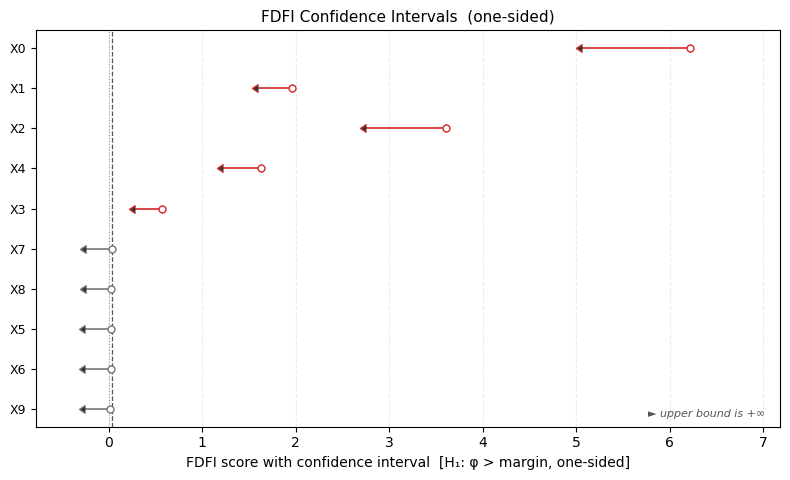

In [8]:
feature_names = [f"X{i}" for i in range(d)]

confidence_interval_plot(
    ci,
    feature_names=feature_names,
    show=False,
)

## Z-Space vs X-Space Importance

The EOT decomposition first computes importance in the disentangled Z-space, then maps back to X-space via the backward weight matrix $W$.


In [9]:
phi_Z = results["phi_Z"]
phi_X = results["phi_X"]

print(f"{'Feature':>8} {'phi_Z':>10} {'phi_X':>10}")
print("-" * 32)
for i in range(d):
    print(f"{'X_' + str(i):>8} {phi_Z[i]:>10.4f} {phi_X[i]:>10.4f}")

print(f"\nTotal phi_Z: {phi_Z.sum():.4f}")
print(f"Total phi_X: {phi_X.sum():.4f}")
print("\nNote: phi_Z measures importance in the disentangled space.")
print("phi_X maps it back to original features via the backward weights W.")


 Feature      phi_Z      phi_X
--------------------------------
     X_0     8.3475     6.2095
     X_1     1.0850     1.9614
     X_2     3.7892     3.6030
     X_3     0.3915     0.5729
     X_4     1.8826     1.6349
     X_5     0.0185     0.0253
     X_6     0.0191     0.0245
     X_7     0.0209     0.0353
     X_8     0.0201     0.0266
     X_9     0.0187     0.0177

Total phi_Z: 15.5931
Total phi_X: 14.1110

Note: phi_Z measures importance in the disentangled space.
phi_X maps it back to original features via the backward weights W.


## Effect of Epsilon on Attribution

Epsilon controls the EOT regularization. Smaller epsilon gives sharper transport (closer to exact OT), while larger epsilon shrinks toward Gaussian transport.


In [10]:
epsilons = [1e-3, 0.01, 0.1]
all_phi = {}

for eps in epsilons:
    exp_eps = EOTExplainer(
        exp_model,
        data=X_train,
        nsamples=60,
        epsilon=eps,
        random_state=0,
    )
    res = exp_eps(X_test)
    all_phi[eps] = res["phi_X"]
    print(f"eps={eps:.2f}  s={exp_eps.s_fwd:.4f}  "
          f"active_mean={res['phi_X'][active_idx].mean():.4f}  "
          f"null_mean={res['phi_X'][[i for i in range(d) if i not in active_idx]].mean():.4f}")

print()
header = f"{'Feature':>8}" + "".join(f"{'eps=' + str(e):>12}" for e in epsilons)
print(header)
print("-" * len(header))
for i in range(d):
    row = f"{'X_' + str(i):>8}"
    for eps in epsilons:
        row += f"{all_phi[eps][i]:>12.4f}"
    print(row)


eps=0.00  s=1.0000  active_mean=3.9655  null_mean=0.3813
eps=0.01  s=1.0000  active_mean=3.9654  null_mean=0.3812
eps=0.10  s=0.9989  active_mean=3.9553  null_mean=0.3801

 Feature   eps=0.001    eps=0.01     eps=0.1
--------------------------------------------
     X_0      6.4625      6.4623      6.4461
     X_1      2.0585      2.0584      2.0513
     X_2      3.7603      3.7602      3.7495
     X_3      0.5681      0.5681      0.5675
     X_4      1.6737      1.6737      1.6705
     X_5      0.0068      0.0068      0.0068
     X_6      0.0049      0.0049      0.0050
     X_7      0.0190      0.0190      0.0191
     X_8      0.0105      0.0105      0.0104
     X_9      0.0009      0.0009      0.0010


## Compare with OTExplainer (Gaussian Baseline)

The `OTExplainer` uses plain Gaussian whitening ($W = L$). The `EOTExplainer` adds the population backward projection ($W = L \cdot M_w$), which can better handle non-Gaussian structure.


In [11]:
from fdfi.explainers import OTExplainer

explainer_ot = OTExplainer(
    exp_model,
    data=X_train,
    nsamples=60,
    random_state=0,
)
results_ot = explainer_ot(X_test)

phi_ot = results_ot["phi_X"]
phi_eot = results["phi_X"]

print(f"{'Feature':>8} {'OT (Gauss)':>12} {'EOT (Semicont)':>15} {'Status':>10}")
print("-" * 49)
for i in range(d):
    status = "model" if i in active_idx else ("corr" if i in relevant_idx else "null")
    print(f"{'X_' + str(i):>8} {phi_ot[i]:>12.4f} {phi_eot[i]:>15.4f} {status:>10}")

ratio_ot = phi_ot[relevant_idx].mean() / phi_ot[null_idx].mean()
ratio_eot = phi_eot[relevant_idx].mean() / phi_eot[null_idx].mean()
print(f"\nRelevant/null ratio (OT):  {ratio_ot:.2f}x")
print(f"Relevant/null ratio (EOT): {ratio_eot:.2f}x")

 Feature   OT (Gauss)  EOT (Semicont)     Status
-------------------------------------------------
     X_0       6.4625          6.2095      model
     X_1       2.0585          1.9614       corr
     X_2       3.7603          3.6030      model
     X_3       0.5681          0.5729       corr
     X_4       1.6737          1.6349      model
     X_5       0.0068          0.0253       null
     X_6       0.0049          0.0245       null
     X_7       0.0190          0.0353       null
     X_8       0.0105          0.0266       null
     X_9       0.0009          0.0177       null

Relevant/null ratio (OT):  344.14x
Relevant/null ratio (EOT): 108.07x


## Diagnostics and Summary

Use `diagnostics` to inspect transport quality and `summary()` for a tabular overview.


Diagnostics:
  Latent independence (median dCor): 0.074783 [GOOD]
  Distribution fidelity (MMD):       0.011061 [GOOD]

Feature Importance Results
Method: EOTExplainer
Number of units: 10
Significance level: 0.05
Alternative: greater
Margin method: gap
Practical margin: 0.0353
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     6.2095     0.6972     5.0628        inf     0.0000   ***
              1     1.9614     0.2225     1.5955        inf     0.0000   ***
              2     3.6030     0.5154     2.7553        inf     0.0000   ***
              3     0.5729     0.1745     0.2858        inf     0.0010   ***
              4     1.6349     0.2475     1.2278        inf     0.0000   ***
              5     0.0253     0.1653    -0.2466        inf     0.5243      
              6     0.024

(<Figure size 1000x400 with 3 Axes>,
 array([<Axes: title={'center': 'FDFI Diagnostics'}, ylabel='Diagnostic value'>,
        <Axes: title={'center': 'Latent dCor Matrix'}>], dtype=object))

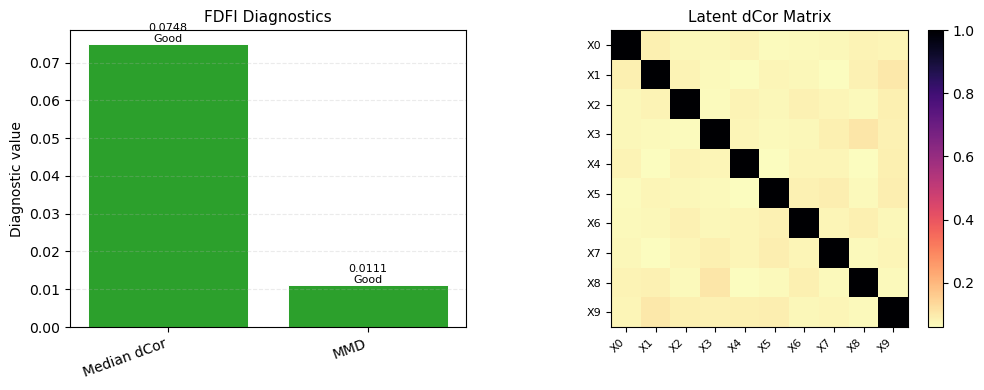

In [12]:
diag = explainer.diagnostics
print("Diagnostics:")
print(f"  Latent independence (median dCor): {diag['latent_independence_median']:.6f} [{diag['latent_independence_label']}]")
print(f"  Distribution fidelity (MMD):       {diag['distribution_fidelity_mmd']:.6f} [{diag['distribution_fidelity_label']}]")
print()

# Standardized summary table
_ = explainer.summary(alpha=0.05, target="X", alternative="greater")


diagnostics_plot(diag, feature_names=feature_names, show=False)


## Quick Reference

```python
from fdfi.explainers import EOTExplainer

explainer = EOTExplainer(
    model,
    data=X_train,
    nsamples=60,
    auto_epsilon=True,   # median-distance heuristic
    random_state=0,
)

results = explainer(X_test)
# results["phi_X"]  — X-space feature importance
# results["phi_Z"]  — Z-space (disentangled) importance

# Attribution inference
ci = explainer.conf_int(alpha=0.05, target="X", alternative="greater")
significant = np.where(ci["reject_null"])[0]

# Inspect transport quality
explainer.diagnostics
```


## Summary

Key takeaways:

1. `EOTExplainer` uses **semicontinuous entropic OT** — the forward map $Z = s \cdot X_w$ is analytical (no Sinkhorn needed).
2. **Population backward attribution** computes $W = L \cdot M_w$ using the best linear projection from the coupling moments.
3. FDFI detects **all features with predictive signal**, including correlated features — not only those directly in the model.
4. `epsilon` controls regularization: smaller → closer to exact OT, larger → more Gaussian shrinkage.
5. Use `auto_epsilon=True` for automatic tuning via the median-distance heuristic.
6. `conf_int()` provides rigorous attribution inference with confidence intervals.